In [1]:
library(tidyr)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
### Example 1: Math Scores

# It might be trick to install the package 'ggm' due to a dependency with another package that is no longer on CRAN..
# To acccess the data, you can alternatively download the file "marks.rda" from the Course OneDrive, and then read it
# into your workspace with readRDS('marks.rda'). 
library(ggm)
data(marks)

In [3]:
### re-fit inverse covariance matrix subject to the following constraints

### Analysis cond. indep. of Mechanics
### Statistics cond. indep. of Mechanics
### Analysis cond. indep of Vectors
### Statistics cond. indep. of Vectors

### 10 possible edges - 4 edges = 6 edges left

# obtain adjacency matrix of this graph
Adj <- matrix(nr = ncol(marks), nc = ncol(marks), data = 1)
diag(Adj) <- 0
Adj[1,c(4,5)] <- 0
Adj[2,c(4,5)] <- 0
Adj[c(4,5),1] <- 0
Adj[c(4,5),2] <- 0
colnames(Adj) <- colnames(marks)
rownames(Adj) <- colnames(marks)

# use function fitConGraph in the package ggm
# this function computes the constrained MLE
# (subject to the constraint that selected off-diagonal entries are zero)
fitPrec <- fitConGraph(Adj, cov(marks), n = nrow(marks), cli = list
(c("vectors", "algebra", "mechanics"),
c("algebra", "analysis", "statistics")))
zapsmall(solve(fitPrec$Shat)*1000)
# note that the selected elements are exactly equal to zero.

,mechanics,vectors,algebra,analysis,statistics
mechanics,5.241303,-2.441762,-2.874358,0.000000,0.000000
vectors,-2.441762,10.345431,-5.607037,0.000000,0.000000
algebra,-2.874358,-5.607037,28.493574,-7.549039,-4.929173
analysis,0.000000,0.000000,-7.549039,9.816193,-2.037784
statistics,0.000000,0.000000,-4.929173,-2.037784,6.440418


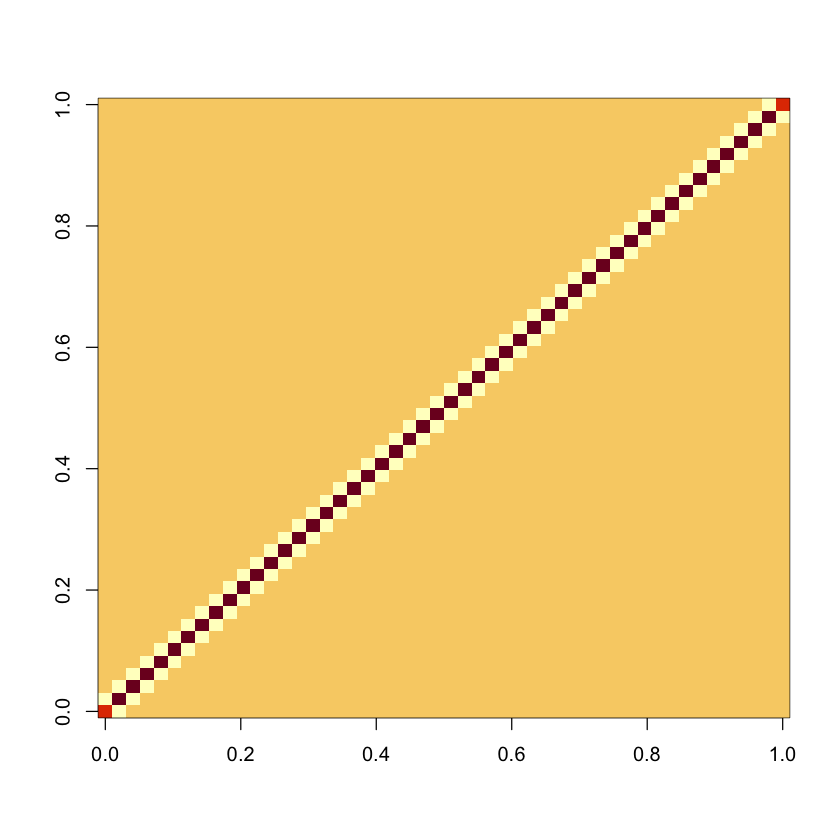

In [4]:
### chaingraph and graphical lasso

set.seed(13)
library(glasso)
library(mvtnorm)
d <- 50
n <- 200 # training data size
n_te <- 500 # test data size


rho <- 0.8
Sigma <- matrix(nrow = d, ncol = d, data = 0)
for(j in 1:d){
    for(k in 1:d){
     Sigma[j,k] <- rho^(abs(j-k))
    }
 }

Omega <- solve(Sigma)
image(Omega) # inverse is a band-matrix with bandwidth 1

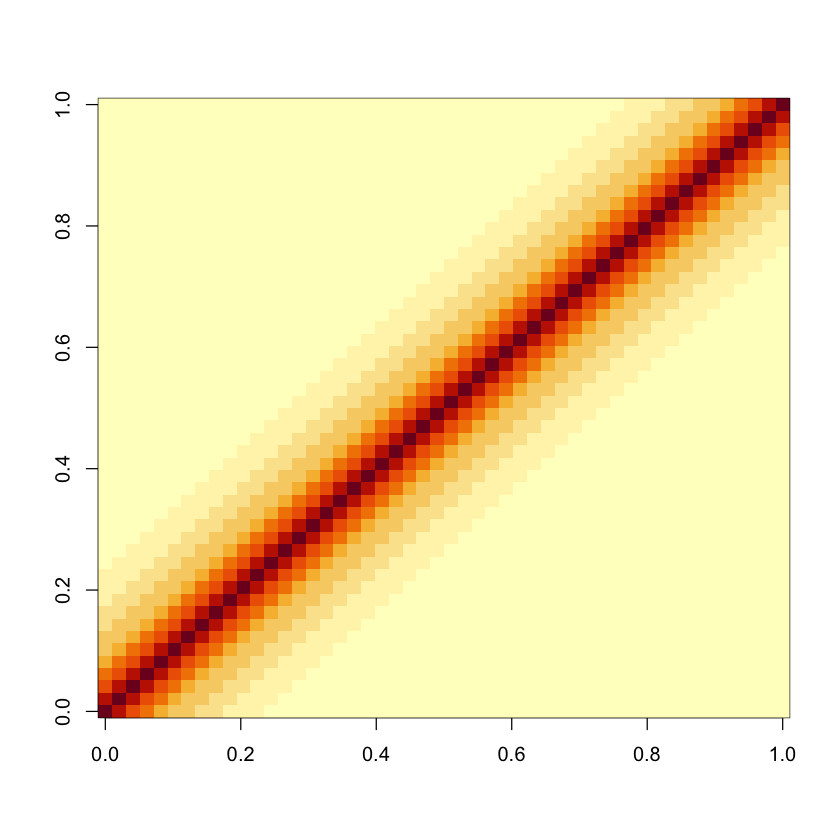

In [15]:
image(Sigma)

rho=
[1] 1
rho=
[1] 0.7943282
rho=
[1] 0.6309573
rho=
[1] 0.5011872
rho=
[1] 0.3981072
rho=
[1] 0.3162278
rho=
[1] 0.2511886
rho=
[1] 0.1995262
rho=
[1] 0.1584893
rho=
[1] 0.1258925
rho=
[1] 0.1
rho=
[1] 0.07943282
rho=
[1] 0.06309573
rho=
[1] 0.05011872
rho=
[1] 0.03981072
rho=
[1] 0.03162278
rho=
[1] 0.02511886
rho=
[1] 0.01995262
rho=
[1] 0.01584893
rho=
[1] 0.01258925
rho=
[1] 0.01
rho=
[1] 0.007943282
rho=
[1] 0.006309573
rho=
[1] 0.005011872
rho=
[1] 0.003981072
rho=
[1] 0.003162278
rho=
[1] 0.002511886
rho=
[1] 0.001995262
rho=
[1] 0.001584893
rho=
[1] 0.001258925
rho=
[1] 0.001


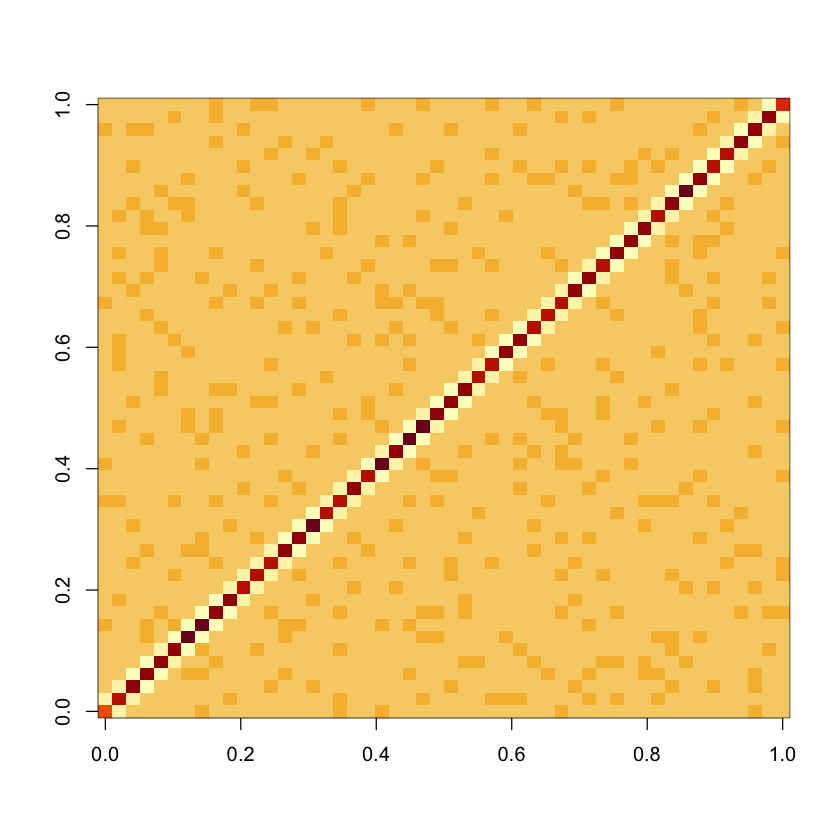

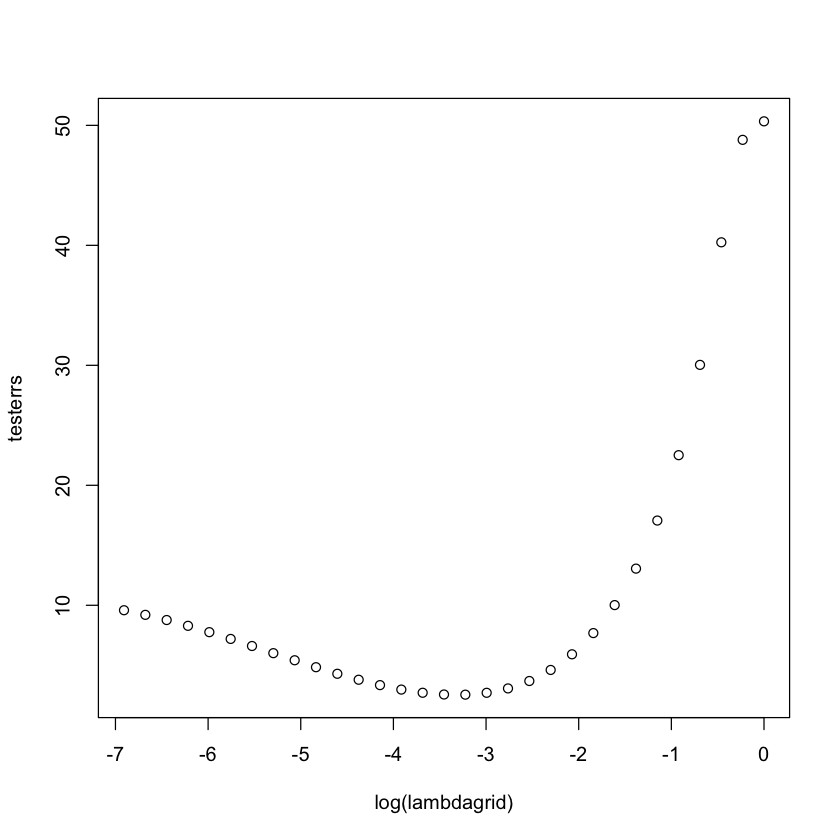

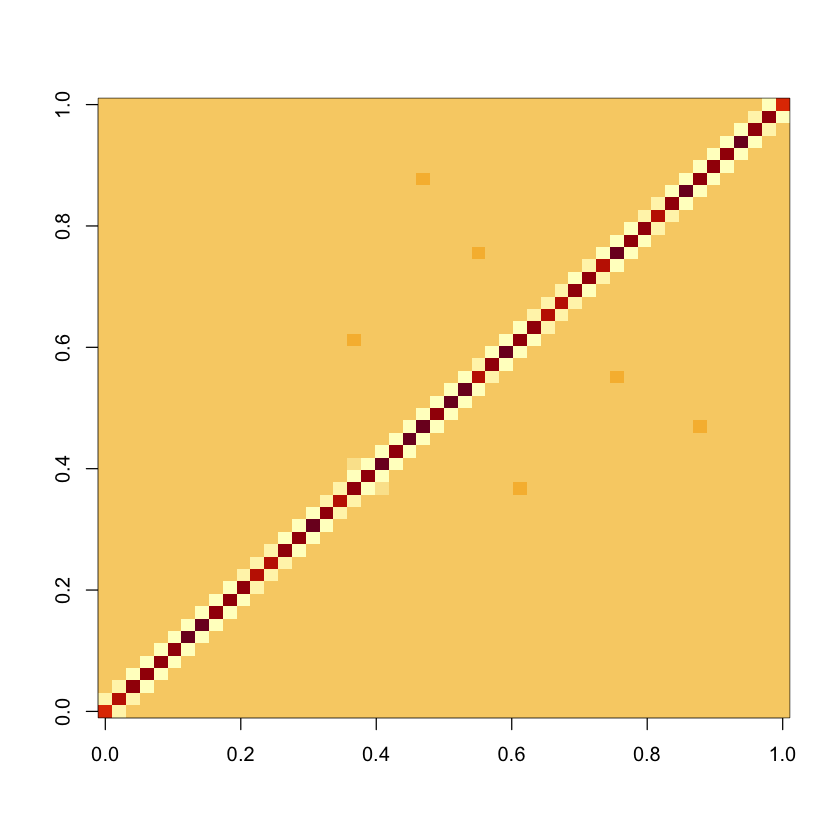

In [10]:
# training data
X <- rmvnorm(n = n, sigma = Sigma)
S <- crossprod(X) / n

# test data
Xtest <- rmvnorm(n = n_te, sigma = Sigma)
Stest <- crossprod(Xtest)/n_te

# fit the graphical lasso to the training data
lambdagrid <- 10^seq(from = -3, to = 0, by = 0.1)#10^seq(from = -4, to = 0, by = 0.25)

glasso_sol <- glassopath(S, rholist = lambdagrid, penalize.diagonal=FALSE)
image(glasso_sol$wi[,,length(lambdagrid)-20])

# Negative log-likelihood (~Stein loss) on the test set
loss <- function(Omegahat) -determinant(Omegahat, log = TRUE)$modulus + sum(Omegahat * Stest)

testerrs <- numeric(length(lambdagrid))

for(k in 1:length(testerrs)){
 testerrs[k] <- loss(glasso_sol$wi[,,k])
}

plot(log(lambdagrid), testerrs)
image(glasso_sol$wi[,,which.min(testerrs)])

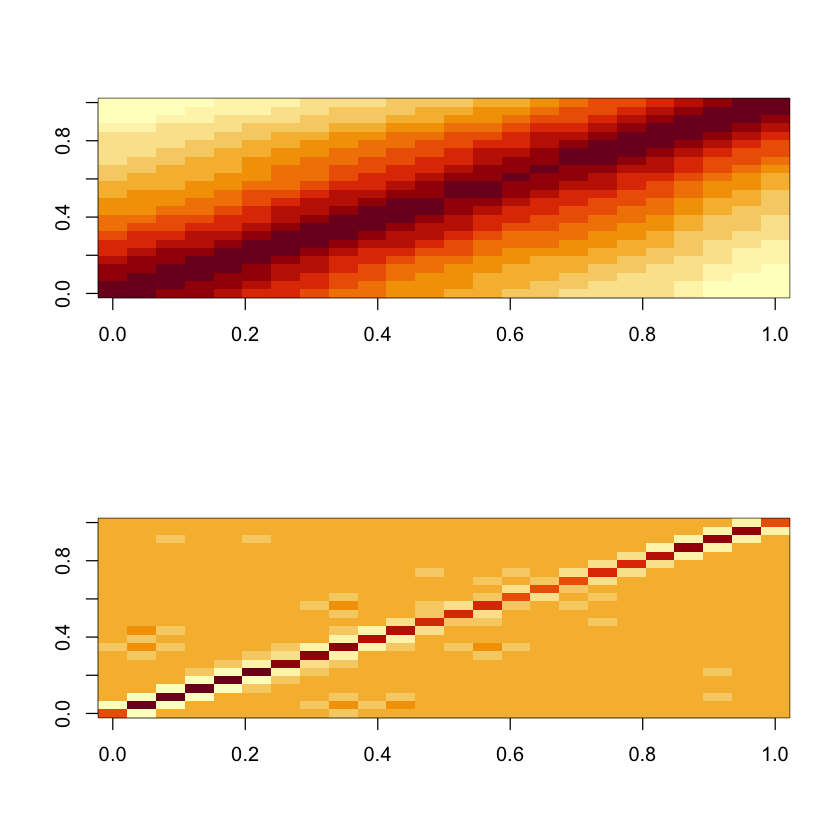

In [11]:
### real data example: an excerpt from the Climate data

# This example follows a similar pattern as the example in
# highdim_PCA.R. The main difference is that the variable
# of interest is now the PM2.5 concentration. As before,
# we extract blocks of 24 hours and consider the 24 hours in a day as variables.
# Different rows are treated as different days (treated independently, for simplicity)

data_all <- readRDS("../../data/climate/data_all.rds")
# extract all data from weather station Nongzhanguan
dat_Nong <- data_all[data_all$station == "Nongzhanguan",]
rm(data_all)

dates <- paste(dat_Nong$month, dat_Nong$day, dat_Nong$year, sep = "-")
dat_day <- dat_Nong %>% select(all_of(c("hour", "day", "month", "year", "PM2.5")))

dat_day_f <- dat_day %>%  pivot_wider(names_from = hour, values_from = PM2.5) %>% drop_na()
dat_final <- dat_day_f %>% select(-all_of(c("day", "month", "year"))) %>% mutate(across(everything(), ~ log(.)))

Cfull <- cor(dat_final)

### --- sparse inverse covariance matrix seems like a suitable model
par(mfrow = c(2,1))
image(Cfull)
image(solve(Cfull))

In [12]:
# select only every 10th data point out of the training set
# (note that training set and test set are supposed be
# non-overlapping, here we ignore this issue for simplicity)

train <- seq(from = 1, to = nrow(dat_final), by = 10)
dat_train <- dat_final[train,]

loss_real <- function(Omegahat) -determinant(Omegahat, log = TRUE)$modulus + sum(Omegahat * Cfull)

glasso_sol <- glassopath(cor(dat_train), rholist = lambdagrid, penalize.diagonal=FALSE)
#image(glasso_sol$wi[,,length(lambdagrid)])

# Stein loss (negative log-likelihood) on the test set

testerrs_real <- numeric(length(lambdagrid))

for(k in 1:length(testerrs)){
 testerrs_real[k] <- loss_real(glasso_sol$wi[,,k])
}

rho=
[1] 1
rho=
[1] 0.7943282
rho=
[1] 0.6309573
rho=
[1] 0.5011872
rho=
[1] 0.3981072
rho=
[1] 0.3162278
rho=
[1] 0.2511886
rho=
[1] 0.1995262
rho=
[1] 0.1584893
rho=
[1] 0.1258925
rho=
[1] 0.1
rho=
[1] 0.07943282
rho=
[1] 0.06309573
rho=
[1] 0.05011872
rho=
[1] 0.03981072
rho=
[1] 0.03162278
rho=
[1] 0.02511886
rho=
[1] 0.01995262
rho=
[1] 0.01584893
rho=
[1] 0.01258925
rho=
[1] 0.01
rho=
[1] 0.007943282
rho=
[1] 0.006309573
rho=
[1] 0.005011872
rho=
[1] 0.003981072
rho=
[1] 0.003162278
rho=
[1] 0.002511886
rho=
[1] 0.001995262
rho=
[1] 0.001584893
rho=
[1] 0.001258925
rho=
[1] 0.001


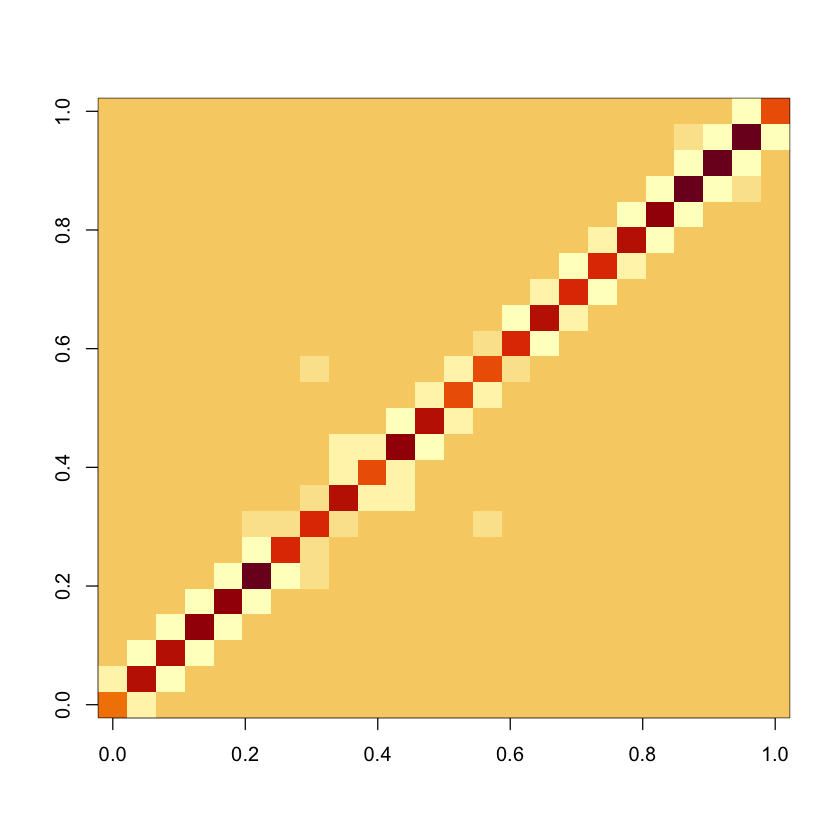

In [13]:
image(glasso_sol$wi[,,which.min(testerrs_real)])

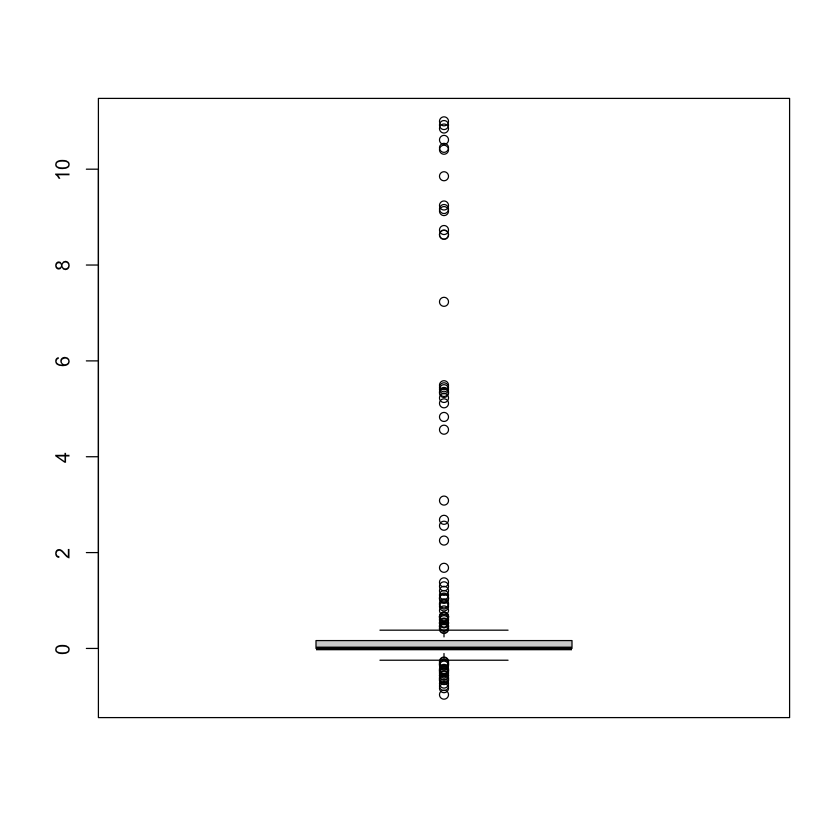

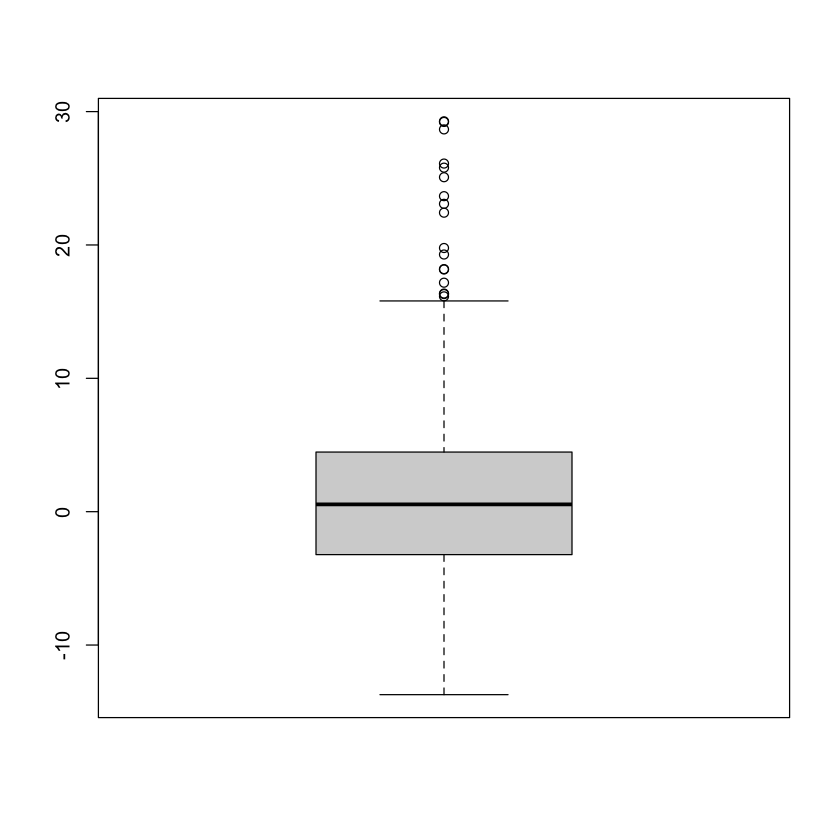

In [14]:
# boxplot off-diagonal entries, w/regularization
Omegahat_real <- glasso_sol$wi[,,which.min(testerrs_real)]
boxplot(-Omegahat_real[lower.tri(Omegahat_real)])
# boxplot w/o regularization
Omegahat_plain <- solve(cor(dat_train))
boxplot(-Omegahat_plain[lower.tri(Omegahat_plain)])